We cluster the MOSAIKS features using KNN and cosine distance.

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd

import glob
import random

from scipy.cluster.vq import kmeans, whiten, vq
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from matplotlib import pyplot as plt

seed = 42

We read all the MOSAIK features and concatenate into one big dataframe

In [2]:
files = glob.glob("/data-store/iplant/home/shared/esiil/Innovation_Summit_2026/Group_12/city_embeddings_cropped/*.parquet")

mosaik_features = pd.concat((pd.read_parquet(f) for f in files), ignore_index=True)
#mosaik_features = pd.read_parquet("/data-store/iplant/home/shared/esiil/Innovation_Summit_2026/Group_12/mosaiks_1757.parquet")

In [3]:
mosaik_features.columns

Index(['lon', 'lat', 'shapeGroup', 'adm2_shapeID_geoBoundaries',
       'adm1_shapeID_geoBoundaries', 'X_0', 'X_1', 'X_2', 'X_3', 'X_4',
       ...
       'X_3990', 'X_3991', 'X_3992', 'X_3993', 'X_3994', 'X_3995', 'X_3996',
       'X_3997', 'X_3998', 'X_3999'],
      dtype='object', length=4005)

In [4]:
mosaik_features.head

<bound method NDFrame.head of            lon     lat shapeGroup adm2_shapeID_geoBoundaries  \
0      153.105 -27.395        AUS    25037944B26487143019559   
1      153.245 -27.485        AUS    25037944B35450059513963   
2      152.975 -27.075        AUS    25037944B19400187923346   
3      152.985 -27.375        AUS    25037944B26487143019559   
4      153.065 -27.365        AUS    25037944B26487143019559   
...        ...     ...        ...                        ...   
84256  115.995 -31.805        AUS    25037944B80977400134390   
84257  115.795 -32.175        AUS    25037944B92381930700505   
84258  115.965 -31.955        AUS     25037944B8488281546819   
84259  115.745 -31.685        AUS     25037944B9363307042095   
84260  115.785 -31.745        AUS    25037944B62034941870385   

      adm1_shapeID_geoBoundaries       X_0       X_1       X_2       X_3  \
0        82085004B13995298844162  0.231240  0.435519  0.101884  0.118524   
1        82085004B13995298844162  0.077583  0.218

In [5]:
mosaik_features.shape

(84261, 4005)

In [6]:
mosaik_features = mosaik_features.iloc[random.sample(range(1, len(mosaik_features)), 1000)]

#mosaik_features = mosaik_features.groupby('continent').apply(lambda x: x.sample(subset,random_state=seed))

Check for unhelpful elements

In [7]:
data = mosaik_features.iloc[:, 5:]

# Check for non-finite values
print("NaNs per column:\n", data.isna().sum())
print("\nInf values:", (~data.apply(lambda x: x.map(np.isfinite))).sum().sum())

# Check for all-zero rows (cosine distance is undefined for zero vectors)
zero_rows = (data == 0).all(axis=1)
print(f"\nAll-zero rows: {zero_rows.sum()}")

# Quick summary
print("\nShape:", data.shape)
print(data.describe())

NaNs per column:
 X_0       0
X_1       0
X_2       0
X_3       0
X_4       0
         ..
X_3995    0
X_3996    0
X_3997    0
X_3998    0
X_3999    0
Length: 4000, dtype: int64

Inf values: 0

All-zero rows: 0

Shape: (1000, 4000)
               X_0          X_1          X_2          X_3          X_4  \
count  1000.000000  1000.000000  1000.000000  1000.000000  1000.000000   
mean      0.211935     0.469830     0.131183     0.153761     0.322195   
std       0.098221     0.198916     0.068630     0.156109     0.144372   
min       0.000110     0.000008     0.000089     0.000000     0.000002   
25%       0.141440     0.340778     0.080521     0.063794     0.219950   
50%       0.198273     0.451335     0.124360     0.109463     0.310285   
75%       0.267520     0.577269     0.168305     0.183276     0.404901   
max       0.573033     1.281940     0.498476     2.059363     0.889162   

               X_5          X_6          X_7          X_8          X_9  ...  \
count  1000.000000  100

Remove unhelpful elements (can't do cosine with 0s)

In [8]:
norms = np.linalg.norm(data.values, axis=1)

# Identify and inspect the problem rows
zero_norm_rows = mosaik_features[norms < 1e-10]
print("Zero-norm rows:")
print(zero_norm_rows)

# Filter them out
data_clean = data[norms >= 1e-10]
print(f"Removed {(norms < 1e-10).sum()} rows, {len(data_clean)} remaining")

Zero-norm rows:
Empty DataFrame
Columns: [lon, lat, shapeGroup, adm2_shapeID_geoBoundaries, adm1_shapeID_geoBoundaries, X_0, X_1, X_2, X_3, X_4, X_5, X_6, X_7, X_8, X_9, X_10, X_11, X_12, X_13, X_14, X_15, X_16, X_17, X_18, X_19, X_20, X_21, X_22, X_23, X_24, X_25, X_26, X_27, X_28, X_29, X_30, X_31, X_32, X_33, X_34, X_35, X_36, X_37, X_38, X_39, X_40, X_41, X_42, X_43, X_44, X_45, X_46, X_47, X_48, X_49, X_50, X_51, X_52, X_53, X_54, X_55, X_56, X_57, X_58, X_59, X_60, X_61, X_62, X_63, X_64, X_65, X_66, X_67, X_68, X_69, X_70, X_71, X_72, X_73, X_74, X_75, X_76, X_77, X_78, X_79, X_80, X_81, X_82, X_83, X_84, X_85, X_86, X_87, X_88, X_89, X_90, X_91, X_92, X_93, X_94, ...]
Index: []

[0 rows x 4005 columns]
Removed 0 rows, 1000 remaining


Cosine distance for hierarchical clusters

In [9]:
z = linkage(data_clean.values, metric='cosine')

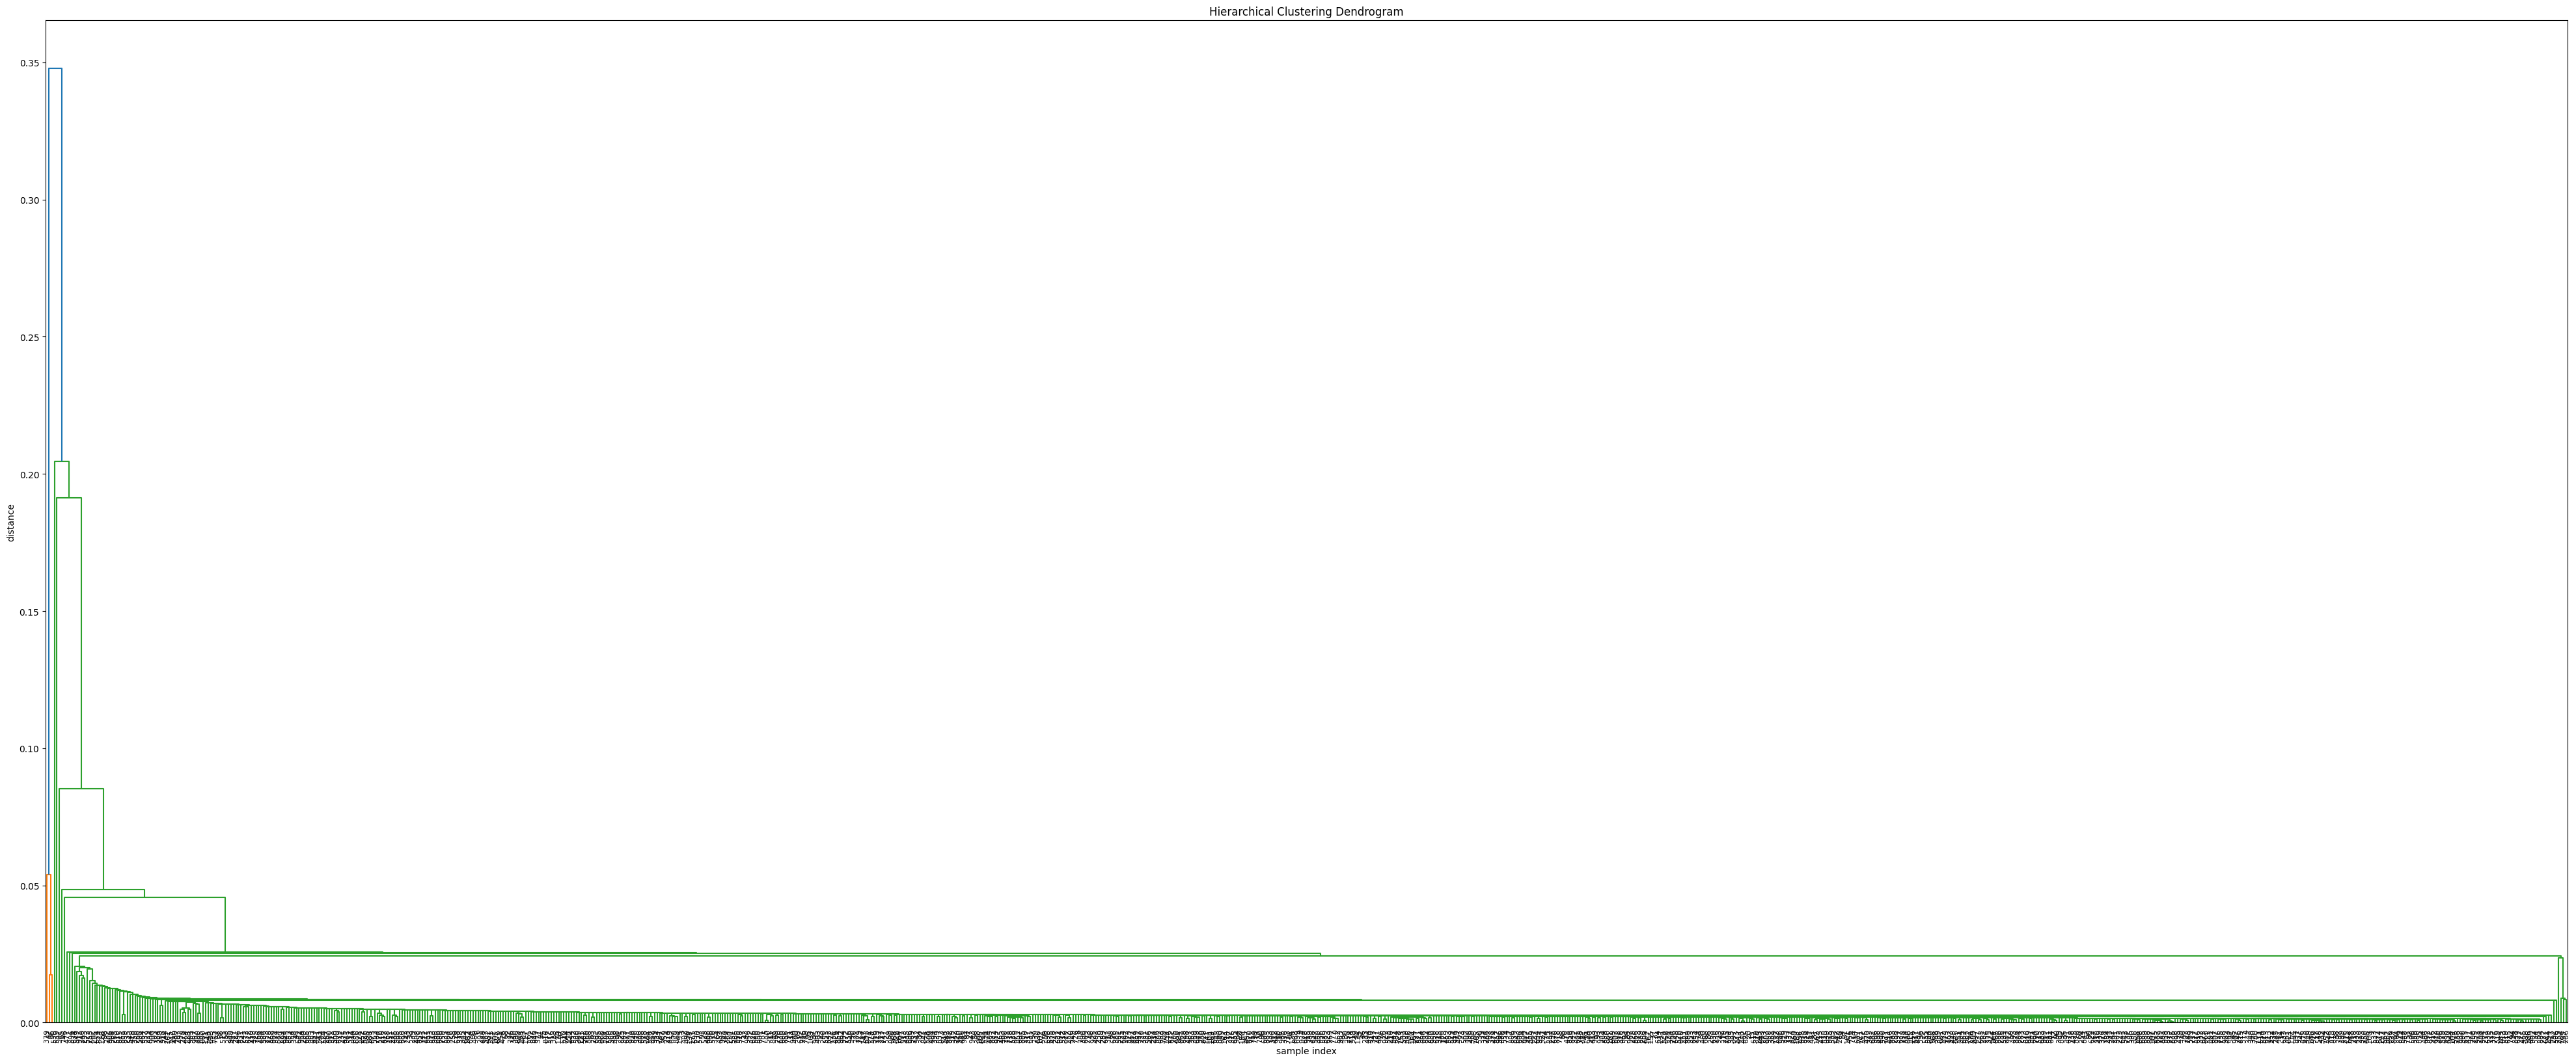

In [10]:
# calculate full dendrogram
plt.figure(figsize=(50, 20))
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('sample index')
plt.ylabel('distance')
dendrogram(
    z,
    leaf_rotation=90.,  # rotates the x axis labels
    leaf_font_size=8.,  # font size for the x axis labels
)
plt.show()

Look at dendogram to decide a threshold for distance. Claude generated code to link back to original dataframe.

In [11]:
# or you can use max cluster to pick the biggest ones
#labels = fcluster(z, t=100, criterion='maxclust')
labels = fcluster(z, t=0.001, criterion='distance')

# --- 2. Build a labeled Series using the cleaned data's index ---
cluster_series = pd.Series(labels, index=data_clean.index, name='cluster')

# --- 3. Join back to the original dataframe ---
mosaik_cluster_labeled = mosaik_features.join(cluster_series)

# Rows that were dropped (zero-norm) will have NaN for cluster
print(mosaik_cluster_labeled['cluster'].value_counts(dropna=False))
print(mosaik_cluster_labeled.shape)

cluster
431    6
392    4
488    3
487    3
395    3
      ..
419    1
114    1
560    1
275    1
387    1
Name: count, Length: 961, dtype: int64
(1000, 4006)


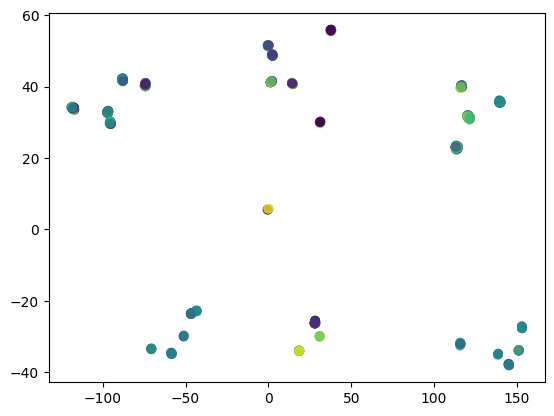

In [12]:
plt.scatter(mosaik_cluster_labeled['lon'], mosaik_cluster_labeled['lat'], c=mosaik_cluster_labeled['cluster'], alpha=0.7)
plt.show()

Export results

In [13]:
mosaik_cluster_labeled.to_csv("/data-store/iplant/home/shared/esiil/Innovation_Summit_2026/Group_12/cluster_results/clusters_cosine.csv", index=False)

In [14]:
gdf = gpd.GeoDataFrame(
    mosaik_cluster_labeled['cluster'], 
    geometry=gpd.points_from_xy(mosaik_cluster_labeled['lon'], mosaik_cluster_labeled['lat']),
    crs="EPSG:4326"
)

gdf.to_file("/data-store/iplant/home/shared/esiil/Innovation_Summit_2026/Group_12/cluster_results/clusters_cosine.geojson", driver='GeoJSON')

OSError: [Errno 121] Remote I/O error: '/data-store/iplant/home/shared/esiil/Innovation_Summit_2026/Group_12/cluster_results/clusters_cosine.geojson'

Now we do KNN

In [ ]:
# --- 1. Whiten the data (normalizes each feature by its std deviation) ---
data_whitened = whiten(data_clean.values)

# --- 2. Fit KMeans ---
centroids, distortion = kmeans(data_whitened, k_or_guess=10, seed=seed)
print(f"Distortion: {distortion:.4f}")

# --- 3. Assign cluster labels ---
labels, distances = vq(data_whitened, centroids)

# --- 4. Join back to original dataframe ---
cluster_series = pd.Series(labels, index=data_clean.index, name='cluster_kmeans')
mosaik_cluster_labeled = mosaik_features.join(cluster_series)

print(mosaik_cluster_labeled['cluster_kmeans'].value_counts(dropna=False))
print(mosaik_cluster_labeled.shape)

/tmp/ipykernel_7136/3584132783.py:2: RuntimeWarning: Some columns have standard deviation zero. The values of these columns will not change.
  data_whitened = whiten(data_clean.values)


In [ ]:
plt.scatter(mosaik_cluster_labeled['lon'], mosaik_cluster_labeled['lat'], c=mosaik_cluster_labeled['cluster_kmeans'], alpha=0.7)
plt.show()

In [ ]:
mosaik_cluster_labeled.to_csv("/data-store/iplant/home/shared/esiil/Innovation_Summit_2026/Group_12/cluster_results/clusters_knn.csv", index=False)

In [ ]:
gdf = gpd.GeoDataFrame(
    mosaik_cluster_labeled['cluster_kmeans'], 
    geometry=gpd.points_from_xy(mosaik_cluster_labeled['lon'], mosaik_cluster_labeled['lat']),
    crs="EPSG:4326"
)

gdf.to_file("/data-store/iplant/home/shared/esiil/Innovation_Summit_2026/Group_12/cluster_results/clusters_knn.geojson", driver='GeoJSON')